In [1]:
import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import scanpy as sc
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.sans-serif"] = ["Arial"]
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

from conv import *
from sarsgt_model import *
from utils import *
import anndata as ad
from collections import Counter
import copy
import dill
from functools import partial
import json
import math
import multiprocessing as mp
import numpy as np
import os
import pandas as pd
from operator import itemgetter
import random
import scipy.sparse as sp
from scipy.io import mmread
from scipy.sparse import hstack, vstack, coo_matrix
import seaborn as sb
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.decomposition import IncrementalPCA
from sklearn.decomposition import SparsePCA
from sklearn.metrics import accuracy_score
from sklearn.metrics.cluster import normalized_mutual_info_score
import time
import torch
import torch.cuda as cuda
from torch import nn
from torch.autograd import Variable
import torch.distributions as D
import torch.nn.functional as F
import torch_geometric.data as Data
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.inits import glorot, uniform
from torch_geometric.utils import softmax as Softmax
from torchmetrics.functional import pairwise_cosine_similarity
import warnings
from warnings import filterwarnings
import xlwt
import argparse
from tqdm import tqdm
from scipy import sparse
from scipy.sparse import csc_matrix,csr_matrix

dataset_name = 'GSE147298_McSC'
batch_remove = False

filterwarnings("ignore")

parser = argparse.ArgumentParser(description='Training GNN on gene cell graph')
parser.add_argument('--seed', type=int, default=0)
parser.add_argument('--fi', type=int, default=0) # This parameter is used for the benchmark to specify the starting sequence number of the created files
parser.add_argument('--labsm', type=float, default=0.1) # The rate of LabelSmoothing
parser.add_argument('--wd', type=float, default=0.1) # The 'weight_decay' parameter is used to specify the strength of L2 regularization
parser.add_argument('--lr', type=float, default=0.0005) # learning rate 0.0005
parser.add_argument('--n_hid', type=int, default=104) # The number of layers should be a multiple of 'n_head' in order to make any modifications
parser.add_argument('--nheads', type=int, default=8) # The 'heads' parameter represents the number of attention heads in the attention mechanism
parser.add_argument('--nlayers', type=int, default=3) # The number of layers in network
parser.add_argument('--cell_size', type=int, default=30) # The number of cells per subgraph (batch)
parser.add_argument('--neighbor', type=int, default=20) # The number of neighboring nodes to be selected for each cell in the subgraph
parser.add_argument('--egrn', type=bool, default=False) # Whether to output the Enhancer-Gene regulatory network
parser.add_argument('--epochs', type=int, default=3) # The epoch number of NodeDimensionReduction
parser.add_argument('--num_epochs', type=int, default=3) # The epoch number of SarsGT-Model
parser.add_argument('--output_file', type=str, default= f'Result/') # Please choose an output path to replace this path on your own.
args = parser.parse_args([])

output_file = args.output_file
fi=args.fi
labsm = args.labsm
lr = args.lr
wd = args.wd
n_hid = args.n_hid
nheads = args.nheads
nlayers = args.nlayers
cell_size = args.cell_size
neighbor = args.neighbor
egrn = args.egrn
epochs = args.epochs
num_epochs = args.num_epochs

seed = args.seed
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

/fs/ess/PAS1475/wangxiaoying/Lxue/miniconda3/envs/marsgt_118/lib/python3.8/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: libcudart.so.10.2: cannot open shared object file: No such file or directory
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/fs/ess/PAS1475/wangxiaoying/Lxue/miniconda3/envs/marsgt_118/lib/python3.8/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: libcudart.so.10.2: cannot open shared object file: No such file or directory
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
/fs/ess/PAS1475/wangxiaoying/Lxue/miniconda3/envs/marsgt_118/lib/python3.8/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: libcudart.so.10.2: cannot open shared object file: No su

In [2]:
# Read h5ad data as input
adata = sc.read_h5ad("Data/dataset_name_adata.h5ad")

In [3]:
import numpy as np
from scipy.sparse import csr_matrix

gene_names = adata.var_names.to_numpy()
cell_names = adata.obs_names.to_numpy()

X = adata.X

if isinstance(X, np.ndarray):
    RNA_matrix = csr_matrix(X.T)
else:
    RNA_matrix = X.T.tocsr()

In [4]:
device = torch.device("cuda" if cuda.is_available() else "cpu")
print('You will use : ',device)
initial_pre = initial_clustering(RNA_matrix)
cluster_ini_num = len(set(initial_pre)) 
ini_p1 = [int(i) for i in initial_pre] 

indices, Node_Ids, dic = batch_select_whole (RNA_matrix, neighbor = [neighbor], cell_size=cell_size)
n_batch = len(indices)

# Reduce the dimensionality of features for cell, gene, and peak data.
node_model = NodeDimensionReduction(RNA_matrix, indices, ini_p1, n_hid=n_hid, n_heads=nheads, 
                                    n_layers=nlayers,labsm=labsm, lr=lr, wd=wd, device=device, num_types=2, num_relations=1, epochs=200)
gnn = node_model.train_model(n_batch=n_batch)

You will use :  cuda
	Using original count matrix for pre-clustering.
         Falling back to preprocessing with `sc.pp.pca` and default params.
We are currently in the process of partitioning the data into batches. Kindly wait for a moment, please.


100%|██████████| 60/60 [00:10<00:00,  5.92it/s]


The training process for the NodeDimensionReduction model has started. Please wait.


100%|██████████| 200/200 [22:24<00:00,  6.72s/it]

The training for the NodeDimensionReduction model has been completed.


In [5]:
SarsGT_model = SarsGT(gnn=gnn, labsm=labsm, n_hid=n_hid, n_batch=n_batch, device=device,lr=lr,wd=wd, num_epochs=50)
SarsGT_gnn = SarsGT_model.train_model(indices=indices,RNA_matrix=RNA_matrix,ini_p1=ini_p1)

SarsGT_result = SarsGT_pred(RNA_matrix,SarsGT_gnn=SarsGT_gnn, indices=indices, 
                    nodes_id=Node_Ids, cell_size=cell_size, device=device, gene_names=gene_names)

The training process for the SarsGT model has started. Please wait.


100%|██████████| 60/60 [00:06<00:00,  8.88it/s]


The training for the SarsGT model has been completed.


100%|██████████| 60/60 [00:03<00:00, 15.33it/s]


### 存储.npy文件

In [29]:
# pred_label，cell_embedding，nodes_id
np.save(output_file + "/Node_Ids_SarsGT.npy", Node_Ids)
np.save(output_file + "/pred_SarsGT.npy", SarsGT_result['pred_label'])
np.save(output_file + "/cell_embedding_SarsGT.npy", SarsGT_result['cell_embedding'])

### 读取.npy文件

In [ ]:
# pred_label，cell_embedding，nodes_id
nodes_id = list(np.load(output_file + "/Node_Ids_SarsGT.npy"))
pred_label = list(np.load(output_file + "/pred_SarsGT.npy"))
cell_embedding = np.load(output_file + "/cell_embedding_SarsGT.npy")

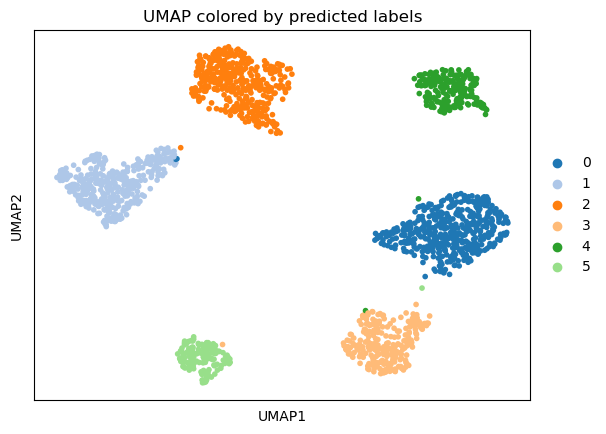

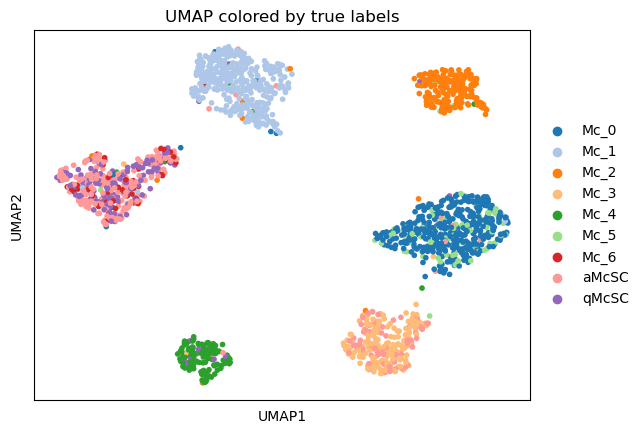

In [11]:
%matplotlib inline

adata_plot = sc.AnnData(cell_embedding)
adata_plot.obs_names = cell_names[nodes_id]

adata_plot.obs['pred_label'] = pd.Categorical(pred_label)
adata_plot.obs['true_label'] = pd.Categorical(list(adata.obs['true_label'].values))[nodes_id]

sc.pp.neighbors(adata_plot, use_rep='X')
sc.tl.umap(adata_plot)

import seaborn as sns
palette = sns.color_palette("tab20") 
sc.pl.umap(adata_plot, color='pred_label', palette=palette, title='UMAP colored by predicted labels')
sc.pl.umap(adata_plot, color='true_label', palette=palette, title='UMAP colored by true labels')